In [38]:
import math             # inclui funções matemáticas como raiz e potência
import pandas as pd     # biblioteca com funções para análise de dados, como carregar dataframes
import numpy as np      # pacote que permite exploração de arrays e manipulação de dados em matrizes
import matplotlib.pyplot as plt
import seaborn as sns   # biblioteca com funções que se integram a pandas e a matplotlib
import scipy
from scipy.stats import variation

In [39]:
#Leitura da planilha
arquivo = "Dados Habitacionais de Ames.xlsx"

df = pd.read_excel(arquivo)
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


Criando DataFrame

In [40]:
df2 = df['SalePrice']
df2

,SalePrice
0,215000
1,105000
2,172000
3,244000
4,189900
...,...
2925,142500
2926,131000
2927,132000
2928,170000


# **Variável 1: Sale Price**

Quartil 1

In [41]:
Q1 = df.SalePrice.quantile(q=0.25)
Q1


np.float64(129500.0)

Quartil 2 | Mediana

In [42]:
Q2 = df.SalePrice.quantile(q=0.5)
Q2

np.float64(160000.0)

Quartil 3

In [43]:
Q3 = df.SalePrice.quantile(q=0.75)
Q3

np.float64(213500.0)

Describe da Variavel SalePrice

In [44]:
df.SalePrice.describe().round(2)

,SalePrice
count,2930.00
mean,180796.06
std,79886.69
min,12789.00
25%,129500.00
50%,160000.00
75%,213500.00
max,755000.00


# Boxplot

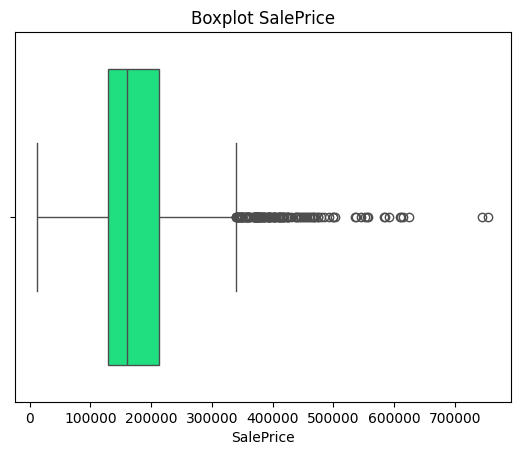

In [45]:
sns.boxplot(df.SalePrice, orient='h', color=[0,1,0.5])
plt.title('Boxplot SalePrice')
plt.show()

Amplitude InterQuartil

In [46]:
AIQ =Q3-Q1
AIQ

np.float64(84000.0)

Limite Inferior & Limite superior


In [47]:
linf = Q1 - 1.5*AIQ
lsup = Q3 + 1.5*AIQ
print("linf =", linf)
print("lsup =", lsup)

linf = 3500.0
lsup = 339500.0


Visualização de Outliers Superiores

In [48]:
df[df.SalePrice>lsup]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
15,16,527216070,60,RL,47.0,53504,Pave,NaN,IR2,HLS,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
17,18,527258010,20,RL,88.0,11394,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,New,Partial,394432
36,37,528108120,60,RL,102.0,12858,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2010,New,Partial,376162
38,39,528120060,20,RL,83.0,10159,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2010,New,Partial,395192
44,45,528150070,20,RL,100.0,12919,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,New,Partial,611657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2666,2667,902400110,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
2737,2738,905427030,75,RL,60.0,19800,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,415000
2883,2884,911370430,120,RM,41.0,5748,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,2,2006,New,Partial,375000
2901,2902,921205030,20,RL,88.0,11443,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2006,New,Partial,369900


Visualização de OutLiers Inferiores

In [49]:
df[df.SalePrice<linf]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


ELIMINANDO OUTLIERS DO DATAFRAME

Usando comando para retirar os outliers do boxplot e do dataframe

In [50]:
df_limpo = df[(df['SalePrice'] >= linf) & (df['SalePrice'] <= lsup)]
display(df_limpo.head())

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


BOXPLOT SEM OUTLIERS

utilizando novo dataframe com dados tratados

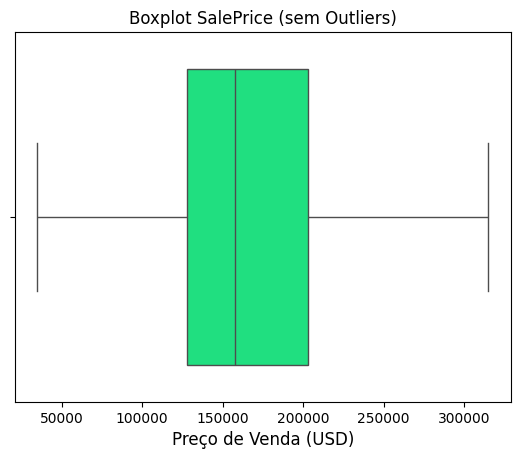

In [51]:
sns.boxplot(df_limpo.SalePrice, orient="h",color=[0,1,0.5] ,showfliers = False)
plt.xlabel('Preço de Venda (USD)',fontsize=12)
plt.title('Boxplot SalePrice (sem Outliers)',fontsize=12)
plt.show()

 # Desvio Padrão

**Desvio Padrão Amostral**

In [52]:
df2.std()

79886.69235666493

**Desvio Padrão Populacional**

In [53]:
df2.std(ddof=0)

79873.05865192247

# Coeficiente de Variação

**Coeficiente de Variação Amostral**

In [54]:
scipy.stats.variation(df2,ddof=1)*100

np.float64(44.186080341852495)

**Coeficiente de Variação Populacional**

In [55]:
scipy.stats.variation(df2,ddof=0)*100

np.float64(44.17853941162574)

# Variavel 2: Área de Lote

## Análise da Variável: Área do Lote (Lot Area)

In [56]:
df_lot_area = df['Lot Area']
df_lot_area

,Lot Area
0,31770
1,11622
2,14267
3,11160
4,13830
...,...
2925,7937
2926,8885
2927,10441
2928,10010


**Quartil 1: Lot Area**

In [57]:
Q1_lot_area = df_lot_area.quantile(q=0.25)
Q1_lot_area

np.float64(7440.25)

**Quartil 2 | Mediana: Lot Area**

In [58]:
Q2_lot_area = df_lot_area.quantile(q=0.5)
Q2_lot_area

np.float64(9436.5)

**Quartil 3: Lot Area**

In [59]:
Q3_lot_area = df_lot_area.quantile(q=0.75)
Q3_lot_area

np.float64(11555.25)

Describe da Variável Lot Area

In [60]:
df_lot_area.describe().round(2)

,Lot Area
count,2930.00
mean,10147.92
std,7880.02
min,1300.00
25%,7440.25
50%,9436.50
75%,11555.25
max,215245.00


# Boxplot: Lot Area

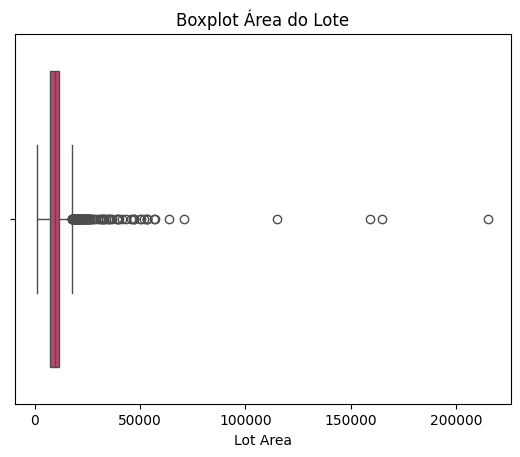

In [61]:
sns.boxplot(df_lot_area, orient='h', color=[0.8, 0.2, 0.4])
plt.title('Boxplot Área do Lote')
plt.show()

Amplitude InterQuartil (AIQ): Lot Area

In [62]:
AIQ_lot_area = Q3_lot_area - Q1_lot_area
AIQ_lot_area

np.float64(4115.0)

Limite Inferior & Limite Superior: Lot Area

In [63]:
linf_lot_area = Q1_lot_area - 1.5 * AIQ_lot_area
lsup_lot_area = Q3_lot_area + 1.5 * AIQ_lot_area
print(f"linf_lot_area = {linf_lot_area}")
print(f"lsup_lot_area = {lsup_lot_area}")

linf_lot_area = 1267.75
lsup_lot_area = 17727.75


Visualização de Outliers Superiores: Lot Area

In [64]:
df[df_lot_area > lsup_lot_area]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
15,16,527216070,60,RL,47.0,53504,Pave,NaN,IR2,HLS,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
18,19,527276150,20,RL,140.0,19138,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,141000
51,52,528218150,20,RL,100.0,18494,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,199500
113,114,534152070,50,RL,NaN,18837,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,212500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2885,2886,913350030,20,RL,69.0,23580,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,9,2006,WD,Normal,242500
2891,2892,916225130,60,RL,42.0,26178,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,335000
2893,2894,916325040,20,RL,NaN,50102,Pave,NaN,IR1,Low,...,0,NaN,NaN,NaN,0,3,2006,WD,Alloca,250764
2903,2904,923125030,20,A (agr),125.0,31250,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,81500


Visualização de Outliers Inferiores: Lot Area

In [65]:
df[df_lot_area < linf_lot_area]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


ELIMINANDO OUTLIERS DO DATAFRAME: Lot Area

Usando comando para retirar os outliers do boxplot e do dataframe

In [66]:
df_lot_area_limpo = df[(df_lot_area >= linf_lot_area) & (df_lot_area <= lsup_lot_area)]
display(df_lot_area_limpo.head())

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500


BOXPLOT SEM OUTLIERS: Lot Area

utilizando novo dataframe com dados tratados

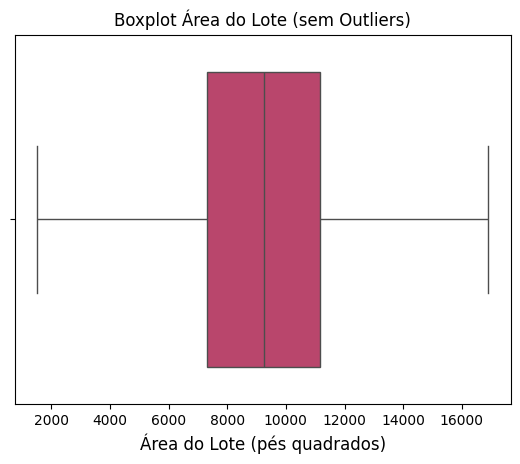

In [67]:
sns.boxplot(df_lot_area_limpo['Lot Area'], orient="h", color=[0.8, 0.2, 0.4], showfliers=False)
plt.xlabel('Área do Lote (pés quadrados)', fontsize=12)
plt.title('Boxplot Área do Lote (sem Outliers)', fontsize=12)
plt.show()

# Desvio Padrão: Lot Area

**Desvio Padrão Amostral: Lot Area**

In [68]:
df_lot_area.std()

7880.017759439081

**Desvio Padrão Populacional: Lot Area**

In [69]:
df_lot_area.std(ddof=0)

7878.672931754667

# Coeficiente de Variação: Lot Area

**Coeficiente de Variação Amostral: Lot Area**

In [70]:
scipy.stats.variation(df_lot_area, ddof=1) * 100

np.float64(77.65154167867433)

**Coeficiente de Variação Populacional: Lot Area**

In [71]:
scipy.stats.variation(df_lot_area, ddof=0) * 100

np.float64(77.6382894315126)